In [1]:
import tensorflow as tf
print(tf.__version__)

2.10.0


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
## Data Preprocessing
## Training Image preprocessing - keras library

In [4]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred", # directory in train taken as label
    label_mode="categorical", # solving multiclass problem (text) --> categorical , not int --> binary class 
    class_names=None, # directory already taken as label 
    color_mode="rgb", 
    batch_size=32,
    image_size=(128, 128),
    shuffle=True, # so as to not introduce bias 
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
) # here we learn how to load image for neural network

Found 70295 files belonging to 38 classes.


In [5]:
# Validation Image Preprocessing

In [6]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [7]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [8]:
for x,y in training_set:
    print(x,x.shape) # x--> training example & y--> labels
    print(y,y.shape)
    break

tf.Tensor(
[[[[197.   189.   200.  ]
   [192.5  184.5  195.5 ]
   [191.5  183.5  194.5 ]
   ...
   [145.25 135.   146.75]
   [143.5  132.5  147.  ]
   [147.75 136.75 153.75]]

  [[194.25 186.25 197.25]
   [199.   191.   202.  ]
   [200.75 192.75 203.75]
   ...
   [139.25 128.25 143.25]
   [149.25 138.   155.5 ]
   [141.25 129.25 150.25]]

  [[191.25 183.25 194.25]
   [193.75 185.75 196.75]
   [199.5  191.5  202.5 ]
   ...
   [134.5  122.75 142.5 ]
   [134.75 122.75 146.25]
   [128.5  116.   141.  ]]

  ...

  [[165.5  153.75 162.25]
   [ 98.    86.    86.  ]
   [ 46.5   30.25  19.75]
   ...
   [137.   126.   143.  ]
   [128.5  117.5  134.5 ]
   [125.75 114.75 131.75]]

  [[148.75 138.75 157.  ]
   [154.25 142.   155.75]
   [101.25  86.    94.  ]
   ...
   [126.25 115.25 132.25]
   [124.   113.   130.  ]
   [121.   110.   127.  ]]

  [[159.5  151.   174.75]
   [148.25 138.25 159.75]
   [163.25 149.75 169.25]
   ...
   [111.   100.   117.  ]
   [118.   107.   124.  ]
   [124.75 113.75 13

In [9]:
#To avoid Overshooting Loss function
#Choose small learning rate default 0.001 here we have taken 0.0001
#There may be chance of underfitting so increase number of neuron , model unable to capture entrie essence of dataset
# to remove underfitting ,add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

In [10]:
#building model
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Dropout
from tensorflow.keras.models import Sequential

In [11]:
model=Sequential()

In [12]:
#building convlutional layer
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3])) # make feature map in such a way that its size os same as input size (matrix size )
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [13]:
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [14]:
model.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [15]:
model.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [16]:
model.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [17]:
model.add(Dropout(0.25))  #droping 25% of whatever layers you are getting ; overfitting 

In [18]:
model.add(Flatten())

In [19]:
model.add(Dense(units=1500,activation='relu'))

In [20]:
model.add(Dropout(0.4)) #droping 40% of neurons from dense layer ; overfitting 

In [21]:
#output layer
model.add(Dense(units=38,activation='softmax'))

In [22]:
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [23]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

In [24]:
#model training 
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=5)

Epoch 1/5
2197/2197 [==============================] - 5531s 3s/step - loss: 1.4614 - accuracy: 0.5720 - val_loss: 0.4932 - val_accuracy: 0.8491
Epoch 2/5
2197/2197 [==============================] - 5797s 3s/step - loss: 0.4892 - accuracy: 0.8457 - val_loss: 0.3055 - val_accuracy: 0.9027
Epoch 3/5
2197/2197 [==============================] - 7070s 3s/step - loss: 0.2932 - accuracy: 0.9054 - val_loss: 0.2659 - val_accuracy: 0.9157
Epoch 4/5
2197/2197 [==============================] - 4958s 2s/step - loss: 0.1991 - accuracy: 0.9352 - val_loss: 0.2278 - val_accuracy: 0.9307
Epoch 5/5
2197/2197 [==============================] - 3762s 2s/step - loss: 0.1506 - accuracy: 0.9503 - val_loss: 0.1806 - val_accuracy: 0.9423


In [25]:
#Evaluating Model
#Training set Accuracy
train_loss, train_acc = model.evaluate(training_set)
print('Training accuracy:', train_acc)

2197/2197 [==============================] - 643s 293ms/step - loss: 0.0772 - accuracy: 0.9742
Training accuracy: 0.9742371439933777


In [26]:
#Validation set Accuracy
val_loss, val_acc = model.evaluate(validation_set)
print('Validation accuracy:', val_acc)

550/550 [==============================] - 164s 298ms/step - loss: 0.1806 - accuracy: 0.9423
Validation accuracy: 0.9422945380210876


In [27]:
model.save('trained_plant_disease_model.keras')

In [28]:
training_history.history #Return Dictionary of history

{'loss': [1.46137273311615,
  0.4892449378967285,
  0.2932209372520447,
  0.19914482533931732,
  0.15061622858047485],
 'accuracy': [0.5719610452651978,
  0.8456931710243225,
  0.9053559899330139,
  0.9352016448974609,
  0.9502667188644409],
 'val_loss': [0.493215411901474,
  0.30551472306251526,
  0.2658669352531433,
  0.22783097624778748,
  0.18063053488731384],
 'val_accuracy': [0.8490780591964722,
  0.9027429819107056,
  0.9157181978225708,
  0.9306851625442505,
  0.9422945380210876]}

In [29]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [30]:
print(training_history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


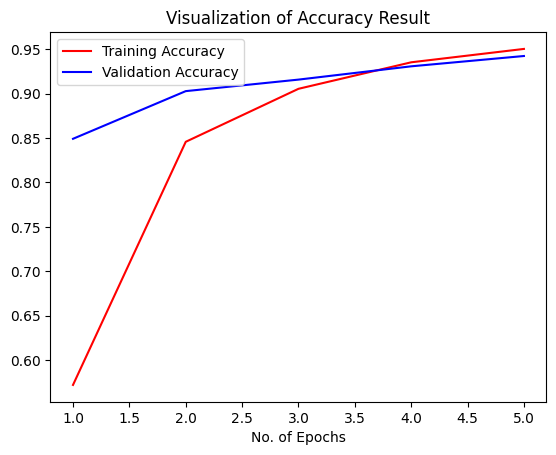

In [31]:
epochs = [i for i in range(1,6)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

In [14]:
#Some other metrics for model evaluation
import tensorflow as tf
import numpy as np
import os

In [15]:
model = tf.keras.models.load_model("trained_plant_disease_model.keras")
print("Model loaded ✅")

Model loaded ✅


In [16]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [17]:
class_name = test_set.class_names
print("Classes:", len(class_name))

Classes: 38


In [18]:
y_pred = model.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

17572/17572 [==============================] - 485s 28ms/step


In [19]:
y_pred,y_pred.shape
print("Prediction completed ✅")
print("Prediction shape:", y_pred.shape)
print("Predicted categories shape:", predicted_categories.shape)

Prediction completed ✅
Prediction shape: (17572, 38)
Predicted categories shape: (17572,)


In [20]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [21]:
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [22]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [23]:
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [24]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [25]:
# Precision Recall Fscore
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.90      0.93      0.92       504
                                 Apple___Black_rot       0.95      0.98      0.97       497
                          Apple___Cedar_apple_rust       0.90      0.98      0.94       440
                                   Apple___healthy       0.92      0.96      0.94       502
                               Blueberry___healthy       0.99      0.93      0.96       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.96      0.97       421
                 Cherry_(including_sour)___healthy       0.98      0.99      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.91      0.84      0.87       410
                       Corn_(maize)___Common_rust_       0.98      1.00      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.80      0.98      0.

In [26]:
cm = confusion_matrix(Y_true,predicted_categories)
cm.shape

(38, 38)

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

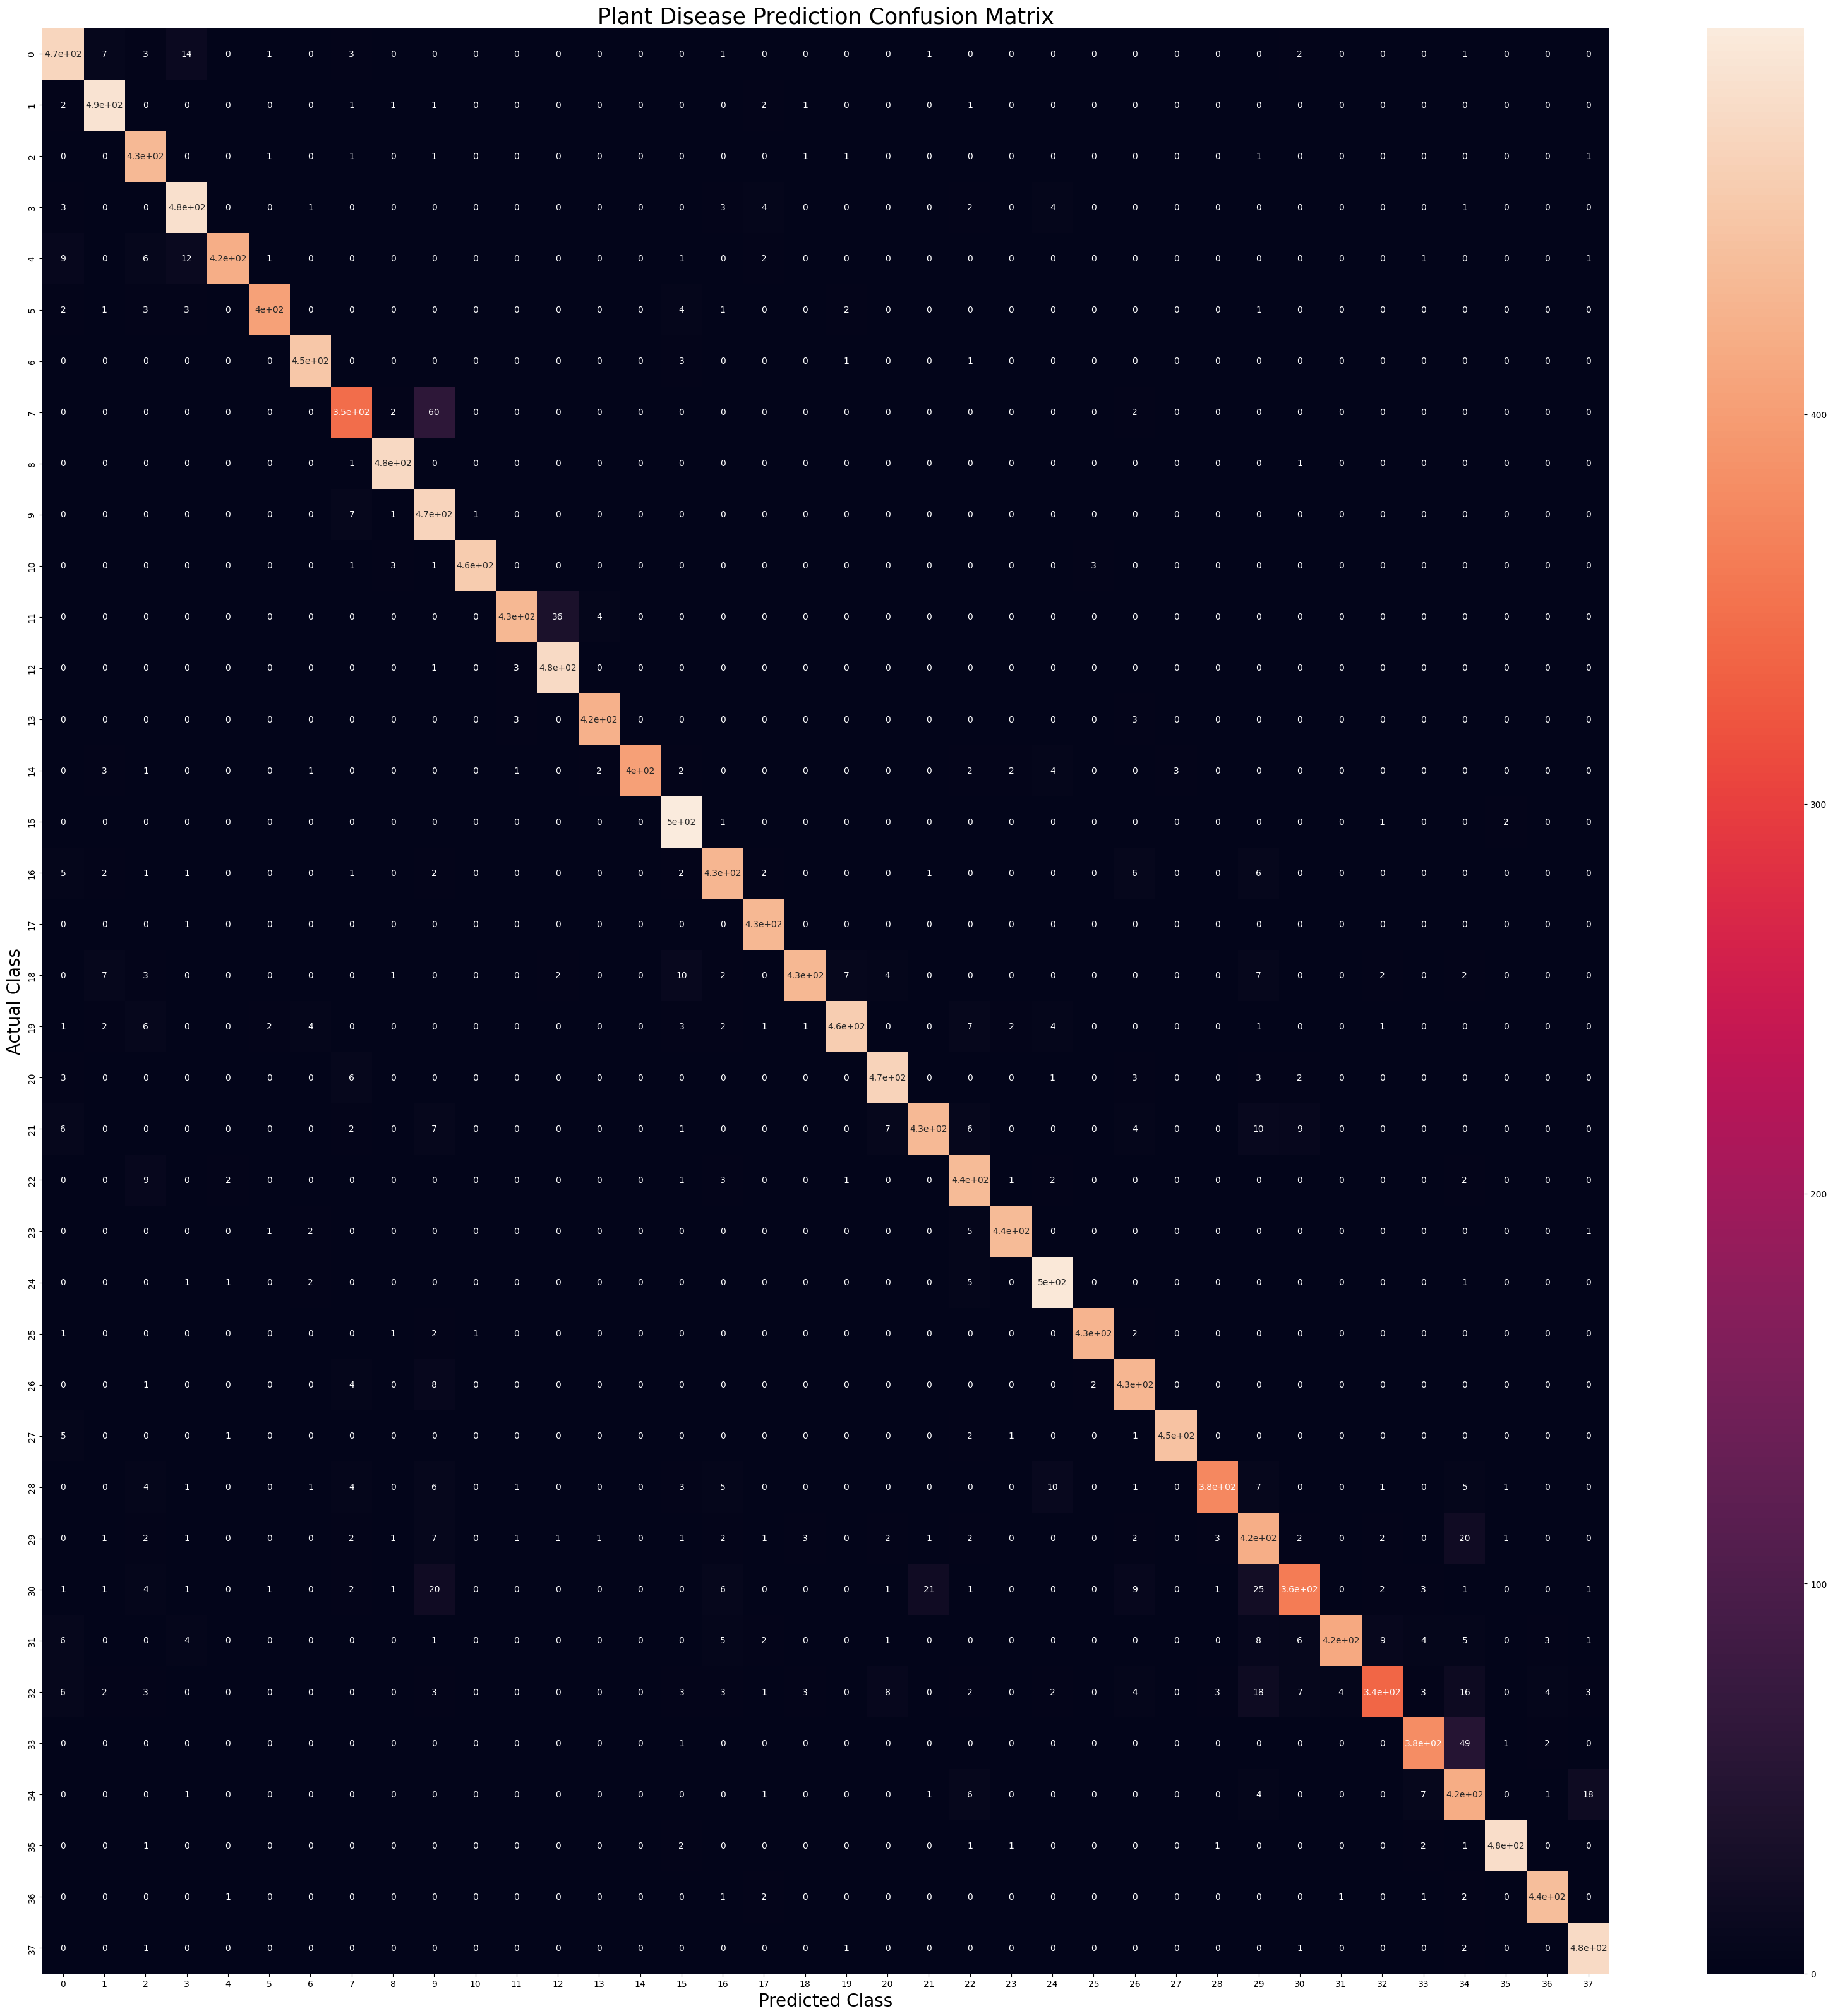

In [29]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()

In [30]:
class_name = test_set.class_names
print("Classes:", len(class_name))
class_name

Classes: 38


['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_